# Customer Churn Prediction System

This project builds an end-to-end machine learning system to predict customer churn using the Telco Customer Churn dataset.

The main objective is to identify customers who are likely to leave a service and understand the key factors behind churn.

## Project Workflow

1. Load the dataset
2. Inspect data structure
3. Clean the dataset
4. Perform exploratory data analysis
5. Build machine learning models
6. Evaluate model performance
7. Explain important features
8. Prepare the project for deployment

In [3]:
# ============================================================
# Customer Churn Prediction System
# Step 1: Import Libraries, Load Dataset, and Basic Inspection
# ============================================================

import os
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# Improve notebook display
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Dataset path from Kaggle input
file_path = "/kaggle/input/datasets/palashfendarkar/wa-fnusec-telcocustomerchurn/WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Load dataset
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("=" * 60)
print(f"Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns")

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

print("\nMissing values before cleaning:")
display(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nTarget variable distribution:")
display(df["Churn"].value_counts())

print("\nTarget variable distribution percentage:")
display(round(df["Churn"].value_counts(normalize=True) * 100, 2))

Dataset loaded successfully.
Dataset shape: 7043 rows and 21 columns

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  70

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Duplicate rows:
0

Target variable distribution:


Churn
No     5174
Yes    1869
Name: count, dtype: int64


Target variable distribution percentage:


Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

In [4]:
# ============================================================
# Step 2: Data Type Investigation and Data Cleaning
# ============================================================

print("Data types before cleaning:")
display(df.dtypes)

print("\nSample values from TotalCharges before conversion:")
display(df["TotalCharges"].head(10))

print("\nFirst 20 unique values from TotalCharges:")
display(df["TotalCharges"].unique()[:20])


def clean_telco_churn_data(dataframe):
    """
    Clean the Telco Customer Churn dataset.

    Cleaning steps:
    1. Convert TotalCharges from object to numeric.
    2. Handle missing values created during numeric conversion.
    3. Drop customerID because it is only an identifier.
    4. Encode the target variable Churn as binary:
       No = 0, Yes = 1.
    """

    df_clean = dataframe.copy()

    # Convert TotalCharges to numeric.
    # Blank or invalid values will become NaN.
    df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

    # Count missing values created after conversion
    missing_total_charges = df_clean["TotalCharges"].isnull().sum()
    print(f"\nMissing values in TotalCharges after conversion: {missing_total_charges}")

    # Fill missing TotalCharges using median
    median_total_charges = df_clean["TotalCharges"].median()
    df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(median_total_charges)

    # Drop customerID because it is not useful for prediction
    if "customerID" in df_clean.columns:
        df_clean = df_clean.drop("customerID", axis=1)

    # Encode target column
    df_clean["Churn"] = df_clean["Churn"].map({"No": 0, "Yes": 1})

    return df_clean


# Apply cleaning function
df_clean = clean_telco_churn_data(df)

print("\nData cleaning completed successfully.")
print("=" * 60)
print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_clean.shape}")

Data types before cleaning:


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


Sample values from TotalCharges before conversion:


0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object


First 20 unique values from TotalCharges:


array(['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5',
       '1949.4', '301.9', '3046.05', '3487.95', '587.45', '326.8',
       '5681.1', '5036.3', '2686.05', '7895.15', '1022.95', '7382.25',
       '528.35', '1862.9'], dtype=object)


Missing values in TotalCharges after conversion: 11

Data cleaning completed successfully.
Original dataset shape: (7043, 21)
Cleaned dataset shape: (7043, 20)


In [5]:
# ============================================================
# Step 3: Validate Cleaned Dataset
# ============================================================

print("Missing values after cleaning:")
display(df_clean.isnull().sum())

print("\nData types after cleaning:")
display(df_clean.dtypes)

print("\nTarget variable distribution after encoding:")
display(df_clean["Churn"].value_counts())

print("\nTarget variable distribution percentage after encoding:")
display(round(df_clean["Churn"].value_counts(normalize=True) * 100, 2))

print("\nCleaned dataset preview:")
display(df_clean.head())

print("\nNumerical summary:")
display(df_clean.describe())

print("\nCategorical summary:")
display(df_clean.describe(include="object"))

Missing values after cleaning:


gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Data types after cleaning:


gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


Target variable distribution after encoding:


...

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1



Numerical summary:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928,0.265370
std,0.368612,24.559481,30.090047,2265.270398,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.500000,402.225000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000



Categorical summary:


,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
top,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
freq,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365


In [6]:
# ============================================================
# Step 4: Save Cleaned Dataset
# ============================================================

cleaned_data_path = "/kaggle/working/cleaned_telco_customer_churn.csv"

df_clean.to_csv(cleaned_data_path, index=False)

print("Cleaned dataset saved successfully.")
print(f"File path: {cleaned_data_path}")

Cleaned dataset saved successfully.
File path: /kaggle/working/cleaned_telco_customer_churn.csv


In [7]:
df_clean.shape
df_clean.head()
df_clean.info()
df_clean["Churn"].value_counts(normalize=True) * 100

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

In [8]:
# ============================================================
# Step 5: Exploratory Data Analysis Setup
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("EDA libraries loaded successfully.")


def churn_rate_table(dataframe, column):
    """
    Create a churn rate summary table for a categorical feature.
    """
    summary = dataframe.groupby(column)["Churn"].agg(["count", "sum", "mean"]).reset_index()
    summary.columns = [column, "Total_Customers", "Churned_Customers", "Churn_Rate"]
    summary["Churn_Rate"] = summary["Churn_Rate"] * 100
    return summary.sort_values("Churn_Rate", ascending=False)

EDA libraries loaded successfully.


Churn Distribution:


Churn
0    5174
1    1869
Name: count, dtype: int64


Churn Distribution Percentage:


Churn
0    73.46
1    26.54
Name: proportion, dtype: float64

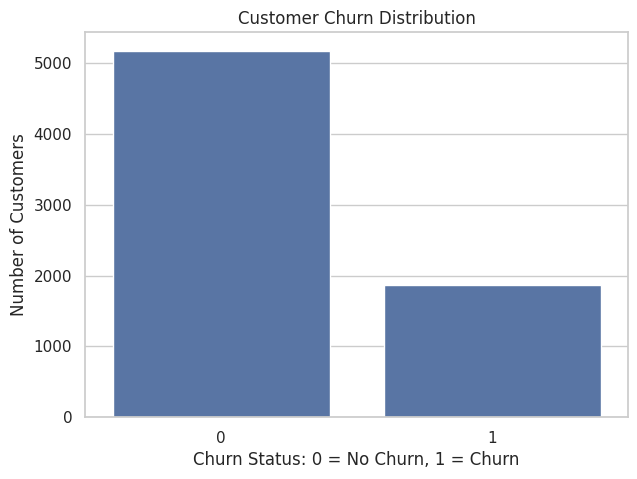

Business Insight:
The dataset is imbalanced. Around 26.54% customers churned, while 73.46% did not churn.
Therefore, accuracy alone will not be enough for model evaluation.


In [9]:
# ============================================================
# Step 6: Target Variable Analysis
# ============================================================

churn_counts = df_clean["Churn"].value_counts()
churn_percentages = df_clean["Churn"].value_counts(normalize=True) * 100

print("Churn Distribution:")
display(churn_counts)

print("\nChurn Distribution Percentage:")
display(round(churn_percentages, 2))

plt.figure(figsize=(7, 5))
sns.countplot(data=df_clean, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status: 0 = No Churn, 1 = Churn")
plt.ylabel("Number of Customers")
plt.show()

print("Business Insight:")
print("The dataset is imbalanced. Around 26.54% customers churned, while 73.46% did not churn.")
print("Therefore, accuracy alone will not be enough for model evaluation.")


Churn Rate by Contract:


,Contract,Total_Customers,Churned_Customers,Churn_Rate
0,Month-to-month,3875,1655,42.709677
1,One year,1473,166,11.269518
2,Two year,1695,48,2.831858


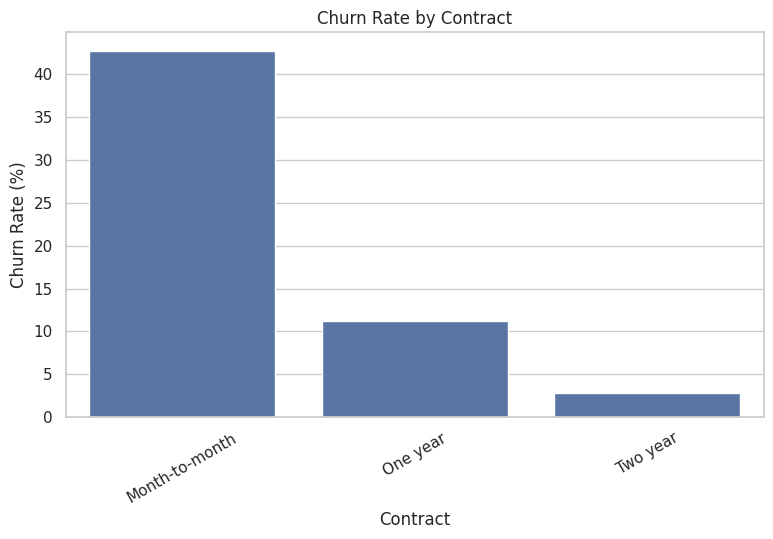


Churn Rate by InternetService:


,InternetService,Total_Customers,Churned_Customers,Churn_Rate
1,Fiber optic,3096,1297,41.892765
0,DSL,2421,459,18.959108
2,No,1526,113,7.404980


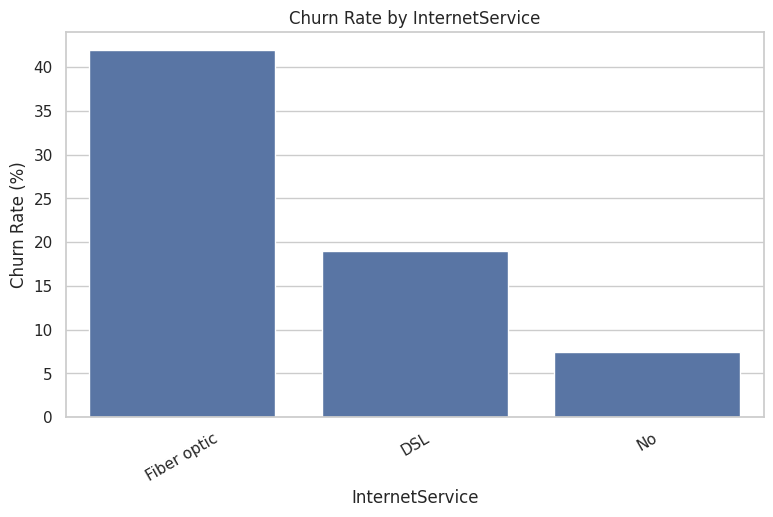


Churn Rate by PaymentMethod:


,PaymentMethod,Total_Customers,Churned_Customers,Churn_Rate
2,Electronic check,2365,1071,45.285412
3,Mailed check,1612,308,19.106700
0,Bank transfer (automatic),1544,258,16.709845
1,Credit card (automatic),1522,232,15.243101


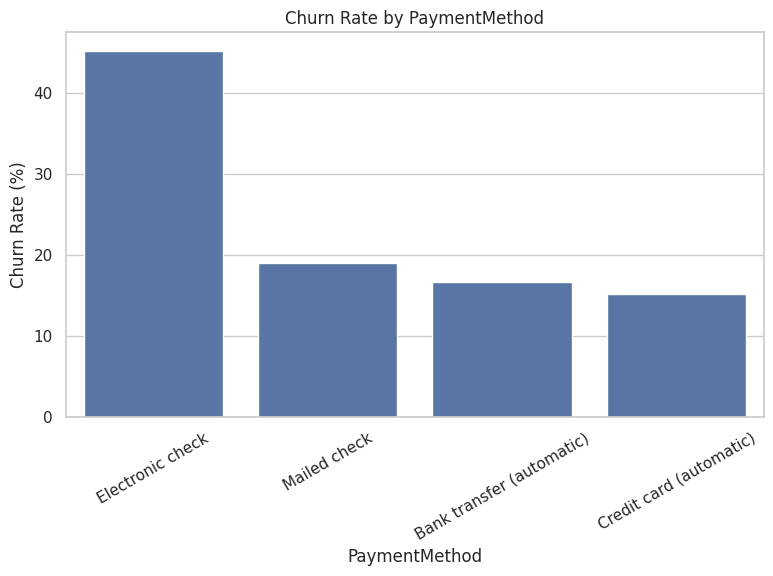

In [10]:
# ============================================================
# Step 7: Key Categorical Feature Analysis
# ============================================================

key_categorical_features = ["Contract", "InternetService", "PaymentMethod"]

for feature in key_categorical_features:
    print(f"\nChurn Rate by {feature}:")
    display(churn_rate_table(df_clean, feature))

    plt.figure(figsize=(9, 5))
    sns.barplot(
        data=churn_rate_table(df_clean, feature),
        x=feature,
        y="Churn_Rate"
    )
    plt.title(f"Churn Rate by {feature}")
    plt.xlabel(feature)
    plt.ylabel("Churn Rate (%)")
    plt.xticks(rotation=30)
    plt.show()

Numerical feature summary by churn status:


,tenure,MonthlyCharges,TotalCharges
Churn,,,
0,37.569965,61.265124,2552.882494
1,17.979133,74.441332,1531.796094


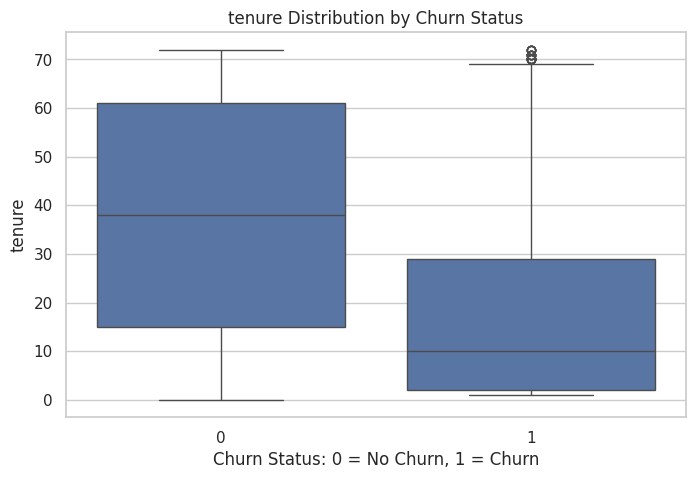

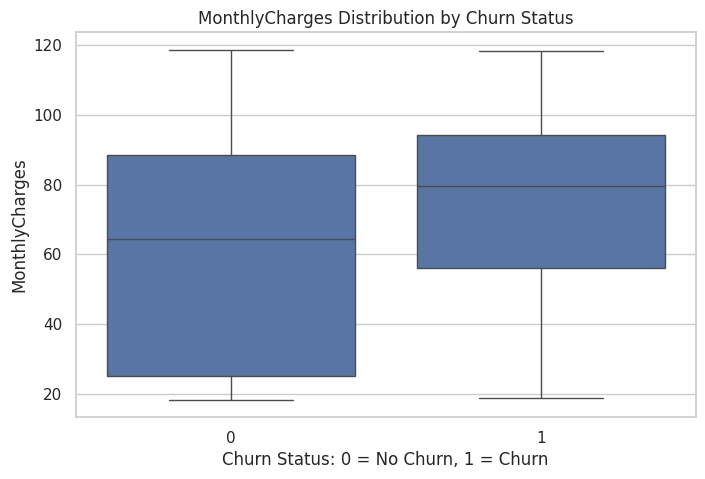

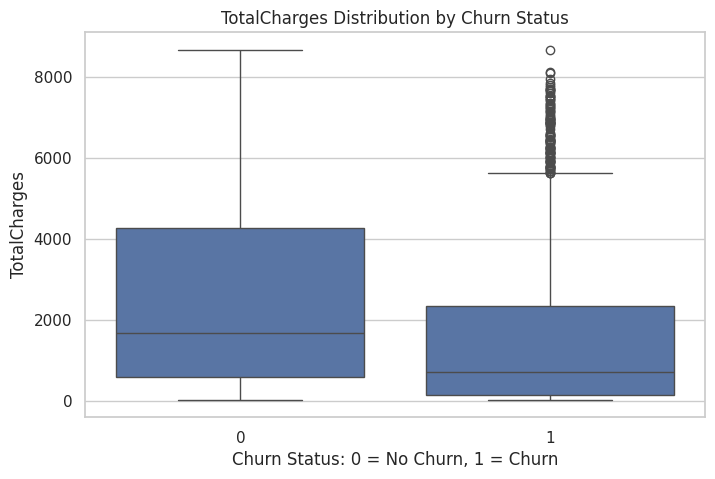

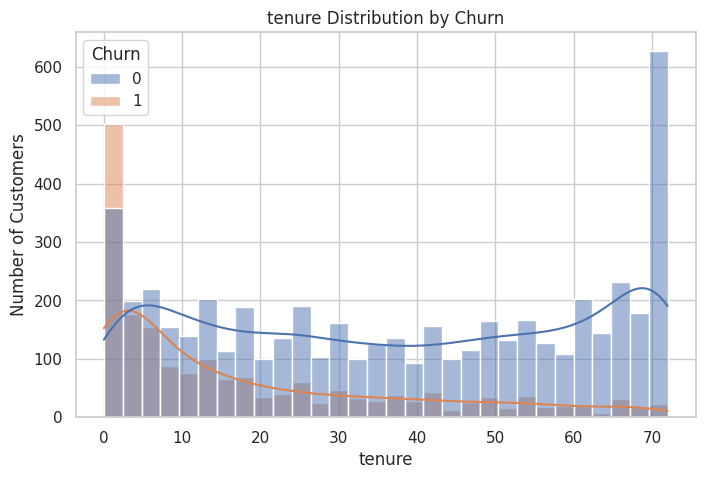

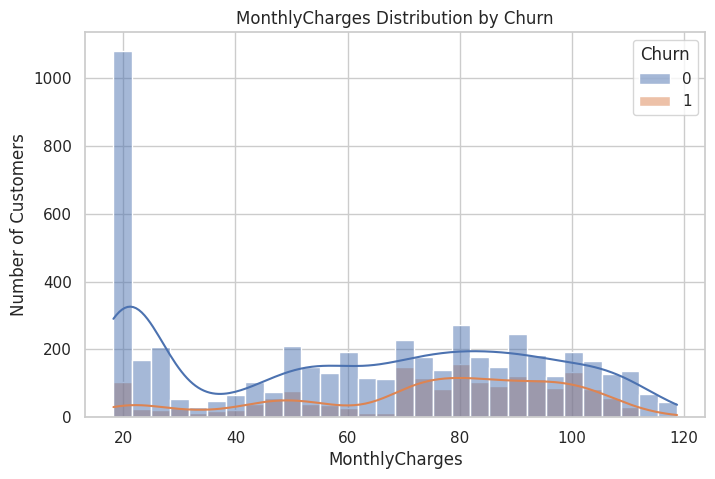

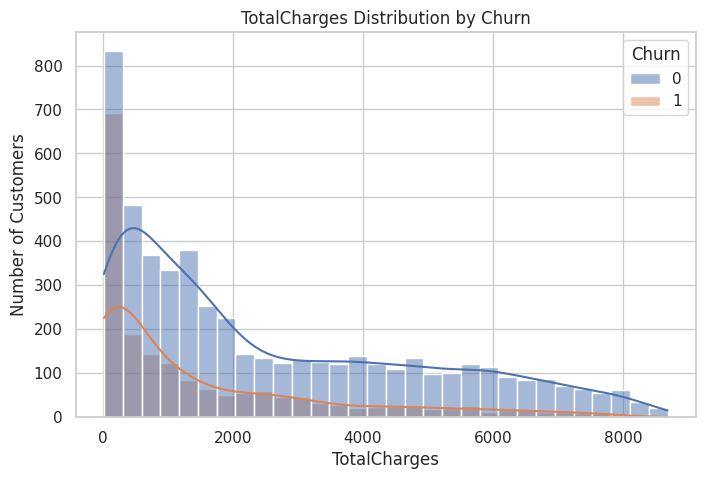

In [11]:
# ============================================================
# Step 8: Numerical Feature Analysis
# ============================================================

numerical_features = ["tenure", "MonthlyCharges", "TotalCharges"]

print("Numerical feature summary by churn status:")
display(df_clean.groupby("Churn")[numerical_features].mean())

for feature in numerical_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_clean, x="Churn", y=feature)
    plt.title(f"{feature} Distribution by Churn Status")
    plt.xlabel("Churn Status: 0 = No Churn, 1 = Churn")
    plt.ylabel(feature)
    plt.show()

for feature in numerical_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df_clean, x=feature, hue="Churn", kde=True, bins=30)
    plt.title(f"{feature} Distribution by Churn")
    plt.xlabel(feature)
    plt.ylabel("Number of Customers")
    plt.show()


Churn Rate by OnlineSecurity:


,OnlineSecurity,Total_Customers,Churned_Customers,Churn_Rate
0,No,3498,1461,41.766724
2,Yes,2019,295,14.611194
1,No internet service,1526,113,7.404980


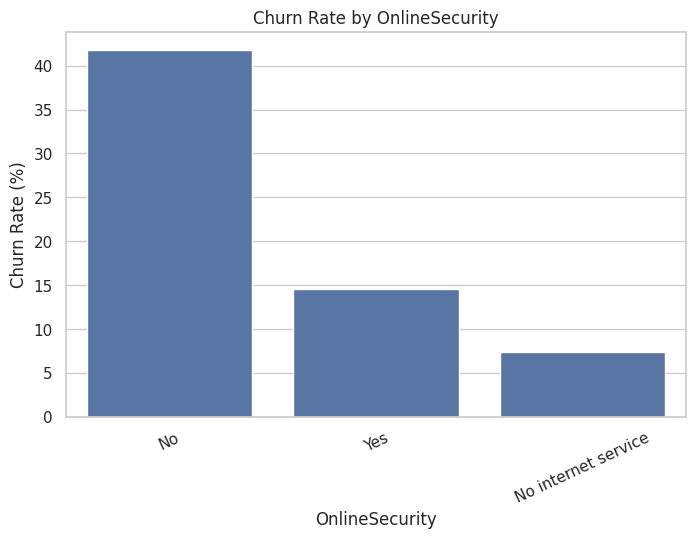


Churn Rate by OnlineBackup:


,OnlineBackup,Total_Customers,Churned_Customers,Churn_Rate
0,No,3088,1233,39.928756
2,Yes,2429,523,21.531494
1,No internet service,1526,113,7.404980


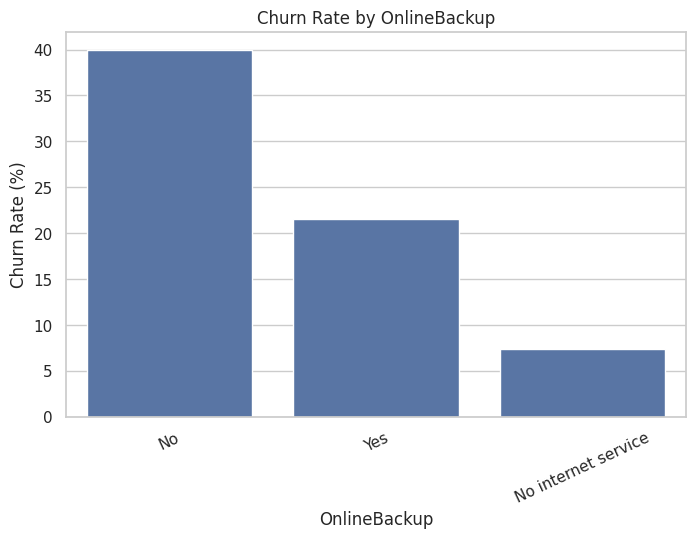


Churn Rate by DeviceProtection:


,DeviceProtection,Total_Customers,Churned_Customers,Churn_Rate
0,No,3095,1211,39.127625
2,Yes,2422,545,22.502064
1,No internet service,1526,113,7.404980


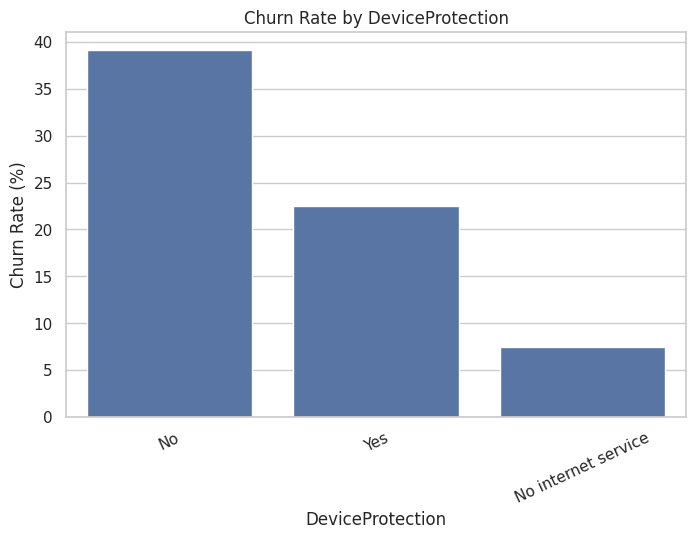


Churn Rate by TechSupport:


,TechSupport,Total_Customers,Churned_Customers,Churn_Rate
0,No,3473,1446,41.635474
2,Yes,2044,310,15.166341
1,No internet service,1526,113,7.404980


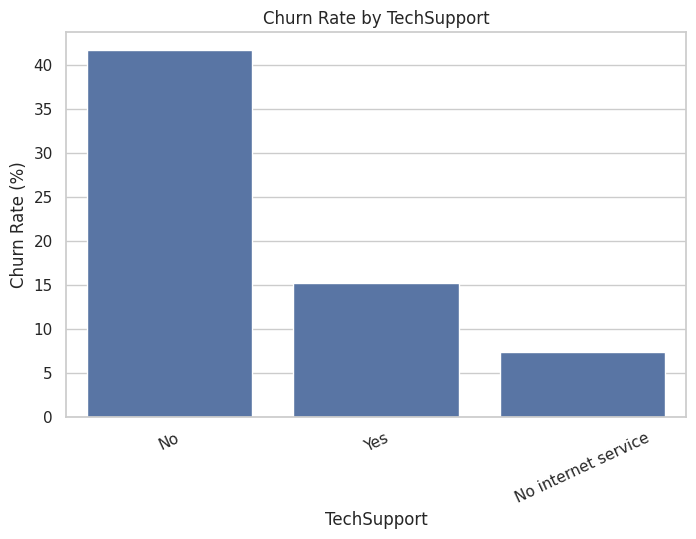


Churn Rate by StreamingTV:


,StreamingTV,Total_Customers,Churned_Customers,Churn_Rate
0,No,2810,942,33.523132
2,Yes,2707,814,30.070188
1,No internet service,1526,113,7.404980


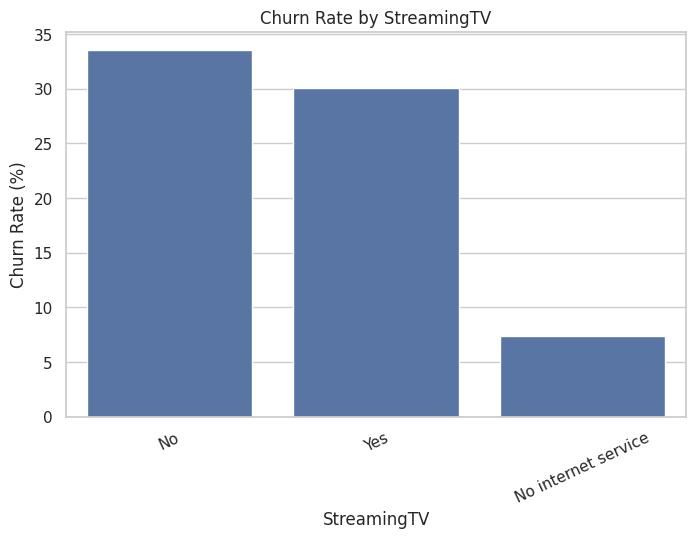


Churn Rate by StreamingMovies:


,StreamingMovies,Total_Customers,Churned_Customers,Churn_Rate
0,No,2785,938,33.680431
2,Yes,2732,818,29.941435
1,No internet service,1526,113,7.404980


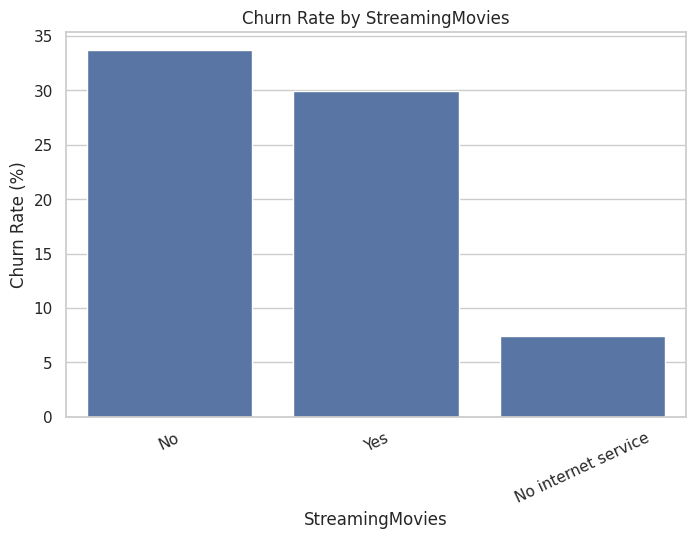


Churn Rate by PaperlessBilling:


,PaperlessBilling,Total_Customers,Churned_Customers,Churn_Rate
1,Yes,4171,1400,33.565092
0,No,2872,469,16.330084


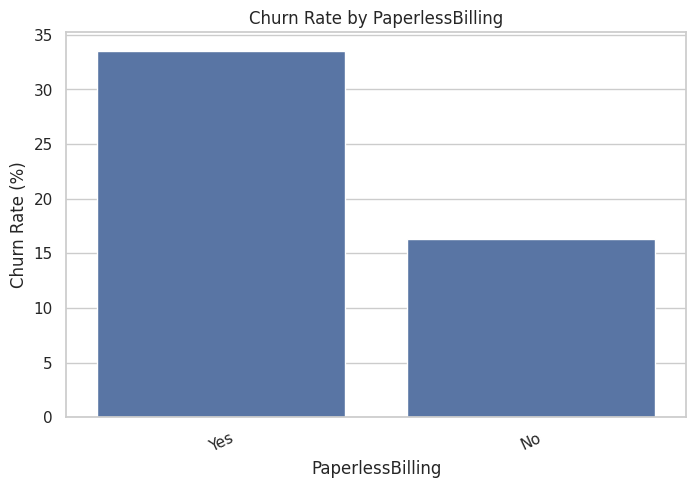

In [12]:
# ============================================================
# Step 9: Service-Based Churn Analysis
# ============================================================

service_features = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling"
]

for feature in service_features:
    print(f"\nChurn Rate by {feature}:")
    display(churn_rate_table(df_clean, feature))

    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=churn_rate_table(df_clean, feature),
        x=feature,
        y="Churn_Rate"
    )
    plt.title(f"Churn Rate by {feature}")
    plt.xlabel(feature)
    plt.ylabel("Churn Rate (%)")
    plt.xticks(rotation=25)
    plt.show()


Churn Rate by gender:


,gender,Total_Customers,Churned_Customers,Churn_Rate
0,Female,3488,939,26.920872
1,Male,3555,930,26.160338


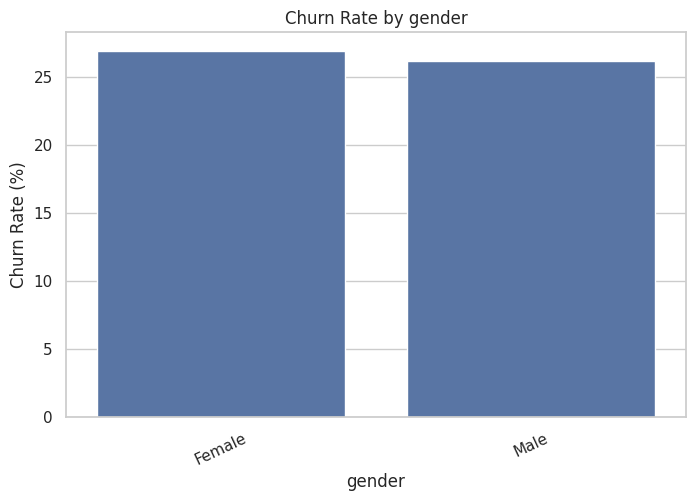


Churn Rate by SeniorCitizen:


,SeniorCitizen,Total_Customers,Churned_Customers,Churn_Rate
1,1,1142,476,41.681261
0,0,5901,1393,23.606168


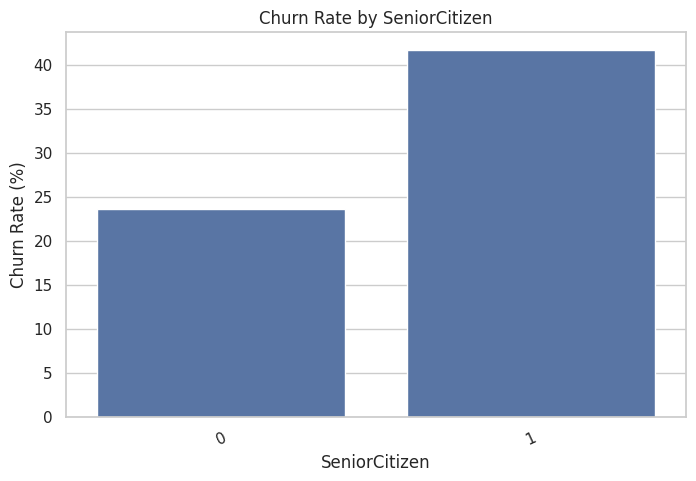


Churn Rate by Partner:


,Partner,Total_Customers,Churned_Customers,Churn_Rate
0,No,3641,1200,32.957979
1,Yes,3402,669,19.664903


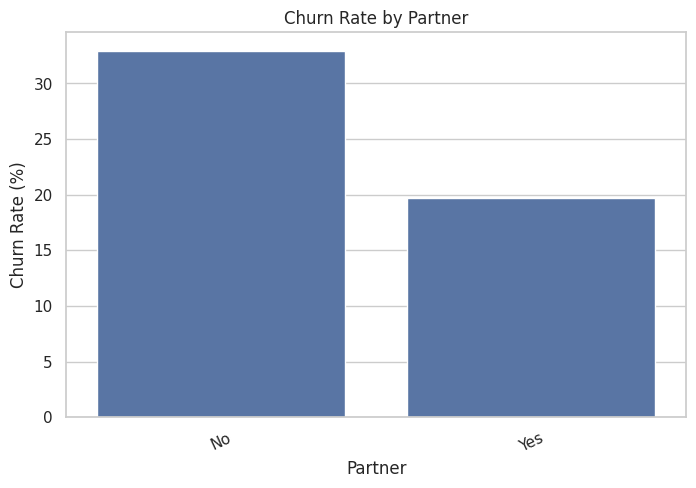


Churn Rate by Dependents:


,Dependents,Total_Customers,Churned_Customers,Churn_Rate
0,No,4933,1543,31.279140
1,Yes,2110,326,15.450237


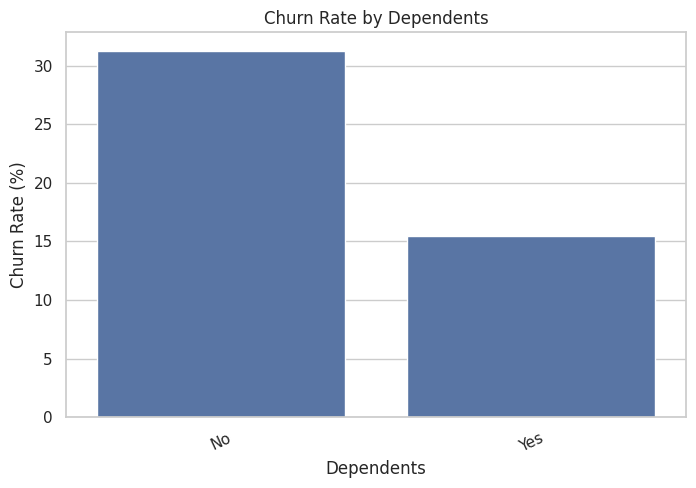


Churn Rate by PhoneService:


,PhoneService,Total_Customers,Churned_Customers,Churn_Rate
1,Yes,6361,1699,26.709637
0,No,682,170,24.926686


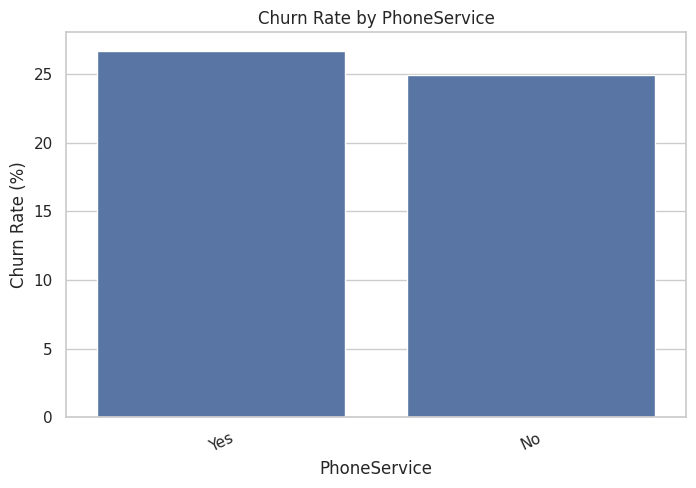


Churn Rate by MultipleLines:


,MultipleLines,Total_Customers,Churned_Customers,Churn_Rate
2,Yes,2971,850,28.609896
0,No,3390,849,25.044248
1,No phone service,682,170,24.926686


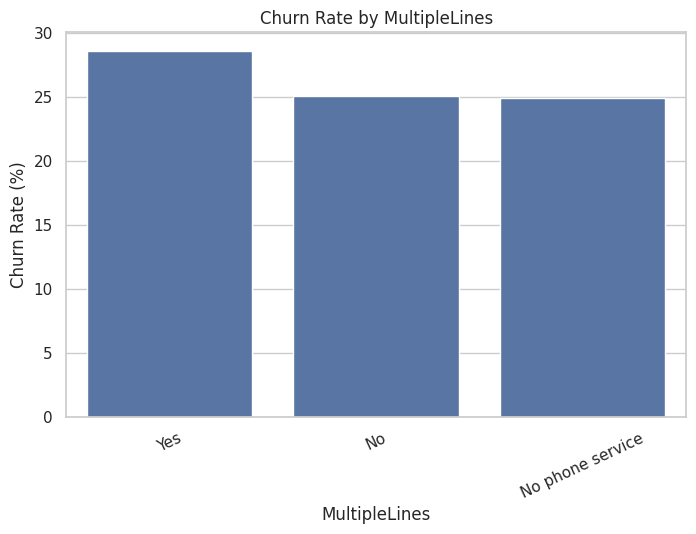

In [13]:
# ============================================================
# Step 10: Customer Profile-Based Churn Analysis
# ============================================================

profile_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines"
]

for feature in profile_features:
    print(f"\nChurn Rate by {feature}:")
    display(churn_rate_table(df_clean, feature))

    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=churn_rate_table(df_clean, feature),
        x=feature,
        y="Churn_Rate"
    )
    plt.title(f"Churn Rate by {feature}")
    plt.xlabel(feature)
    plt.ylabel("Churn Rate (%)")
    plt.xticks(rotation=25)
    plt.show()

In [14]:
# ============================================================
# Step 11: EDA Summary
# ============================================================

print("EDA SUMMARY")
print("=" * 60)

print("1. The dataset is imbalanced:")
print("   - No Churn customers: 73.46%")
print("   - Churn customers: 26.54%")

print("\n2. Contract type is expected to be a strong churn factor.")
print("   - Month-to-month customers usually show higher churn risk.")

print("\n3. Tenure is expected to be inversely related to churn.")
print("   - Newer customers are usually more likely to churn.")

print("\n4. Monthly charges may influence churn.")
print("   - Customers with higher monthly charges may show higher churn tendency.")

print("\n5. Service-related features such as OnlineSecurity and TechSupport may affect churn.")
print("   - Lack of support/security services may increase churn probability.")

print("\n6. Because the target variable is imbalanced, model evaluation should focus on:")
print("   - Precision")
print("   - Recall")
print("   - F1-score")
print("   - ROC-AUC")

EDA SUMMARY
1. The dataset is imbalanced:
   - No Churn customers: 73.46%
   - Churn customers: 26.54%

2. Contract type is expected to be a strong churn factor.
   - Month-to-month customers usually show higher churn risk.

3. Tenure is expected to be inversely related to churn.
   - Newer customers are usually more likely to churn.

4. Monthly charges may influence churn.
   - Customers with higher monthly charges may show higher churn tendency.

5. Service-related features such as OnlineSecurity and TechSupport may affect churn.
   - Lack of support/security services may increase churn probability.

6. Because the target variable is imbalanced, model evaluation should focus on:
   - Precision
   - Recall
   - F1-score
   - ROC-AUC


Feature Engineering → ML Pipeline → Model Comparison → Best Model Selection

In [15]:
# ============================================================
# Step 12: Feature Engineering and Train-Test Split
# ============================================================

from sklearn.model_selection import train_test_split

def create_customer_churn_features(dataframe):
    """
    Create additional business-relevant features for customer churn prediction.
    
    These features help the model capture customer behavior patterns such as:
    - customer lifecycle stage
    - service usage depth
    - contract risk
    - internet service availability
    """

    data = dataframe.copy()

    # Group customers by tenure duration
    data["TenureGroup"] = pd.cut(
        data["tenure"],
        bins=[-1, 12, 24, 48, 72],
        labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"]
    ).astype("object")

    # Identify whether customer has internet service
    data["HasInternetService"] = np.where(data["InternetService"] == "No", "No", "Yes")

    # Identify month-to-month contract customers
    data["IsMonthToMonth"] = np.where(data["Contract"] == "Month-to-month", "Yes", "No")

    # Count number of important support/security services used by customer
    support_service_cols = [
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport"
    ]

    data["NumberOfSupportServices"] = data[support_service_cols].apply(
        lambda row: sum(row == "Yes"), axis=1
    )

    # Average spending intensity across tenure
    data["AverageChargesPerTenure"] = data["TotalCharges"] / data["tenure"].replace(0, 1)

    return data


# Apply feature engineering
df_model = create_customer_churn_features(df_clean)

print("Feature engineering completed successfully.")
print(f"Dataset shape after feature engineering: {df_model.shape}")

print("\nNewly created features:")
new_features = [
    "TenureGroup",
    "HasInternetService",
    "IsMonthToMonth",
    "NumberOfSupportServices",
    "AverageChargesPerTenure"
]
display(df_model[new_features].head())

# Separate features and target
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

# Identify numerical and categorical features
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

# Train-test split with stratification to preserve churn ratio
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain-test split completed.")
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
display(y_test.value_counts(normalize=True) * 100)

Feature engineering completed successfully.
Dataset shape after feature engineering: (7043, 25)

Newly created features:


,TenureGroup,HasInternetService,IsMonthToMonth,NumberOfSupportServices,AverageChargesPerTenure
0,0-12 months,Yes,Yes,1,29.850000
1,25-48 months,Yes,No,2,55.573529
2,0-12 months,Yes,Yes,2,54.075000
3,25-48 months,Yes,No,3,40.905556
4,0-12 months,Yes,Yes,0,75.825000



Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'NumberOfSupportServices', 'AverageChargesPerTenure']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup', 'HasInternetService', 'IsMonthToMonth']

Train-test split completed.
Training set shape: (5634, 24)
Testing set shape: (1409, 24)

Training target distribution:


Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64


Testing target distribution:


Churn
0    73.456352
1    26.543648
Name: proportion, dtype: float64

In [16]:
# ============================================================
# Step 13: ML Pipeline, Model Training, and Model Comparison
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Preprocessing pipeline
# Numerical features are scaled.
# Categorical features are one-hot encoded.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Class imbalance handling for XGBoost
negative_count = y_train.value_counts()[0]
positive_count = y_train.value_counts()[1]
scale_pos_weight = negative_count / positive_count

print(f"Scale positive weight for XGBoost: {scale_pos_weight:.2f}")

# Define models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42
    )
}

trained_models = {}
model_results = []

for model_name, classifier in models.items():
    print(f"\nTraining {model_name}...")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", classifier)
        ]
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1_Score": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_proba)
    }

    trained_models[model_name] = pipeline
    model_results.append(results)

    print(f"{model_name} training completed.")

# Create model comparison table
model_results_df = pd.DataFrame(model_results)
model_results_df = model_results_df.sort_values(by="ROC_AUC", ascending=False)

print("\nModel Comparison Results:")
display(model_results_df)

Scale positive weight for XGBoost: 2.77

Training Logistic Regression...
Logistic Regression training completed.

Training Random Forest...
Random Forest training completed.

Training XGBoost...
XGBoost training completed.

Model Comparison Results:


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.733854,0.499160,0.794118,0.613003,0.842104
2,XGBoost,0.753726,0.524954,0.759358,0.620765,0.841733
1,Random Forest,0.770050,0.551653,0.713904,0.622378,0.840097


Best model selected: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.80      1035
       Churn       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.73      0.75      1409


Confusion Matrix:


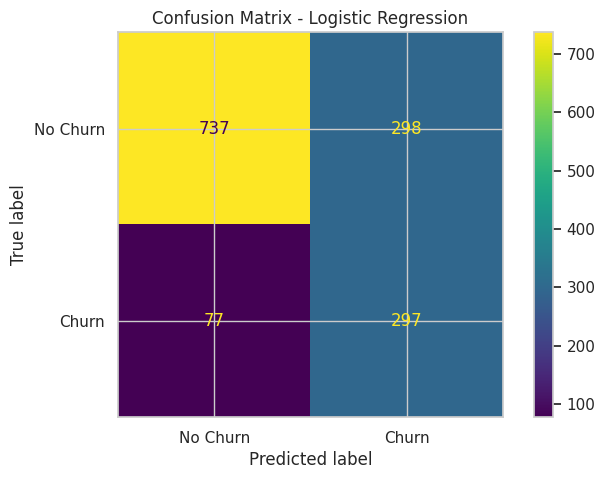


Best Model Performance Summary:
Accuracy : 0.7339
Precision: 0.4992
Recall   : 0.7941
F1 Score : 0.6130
ROC-AUC  : 0.8421


In [17]:
# ============================================================
# Step 14: Best Model Selection and Detailed Evaluation
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Select best model based on ROC-AUC
best_model_name = model_results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print(f"Best model selected: {best_model_name}")

# Predictions
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_best,
    target_names=["No Churn", "Churn"]
))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

print("\nBest Model Performance Summary:")
print(f"Accuracy : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_best):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba_best):.4f}")

In [18]:
# ============================================================
# Step 15: Threshold Tuning for Business-Oriented Prediction
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

thresholds = np.arange(0.10, 0.91, 0.01)
threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba_best >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
    
    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1_Score": f1_score(y_test, y_pred_threshold, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_proba_best),
        "True_Negative": tn,
        "False_Positive": fp,
        "False_Negative": fn,
        "True_Positive": tp
    })

threshold_results_df = pd.DataFrame(threshold_results)

# Business logic:
# For churn prediction, recall is important because missing a churn customer is costly.
# We first try to keep recall >= 0.75, then select the best F1-score.
candidate_thresholds = threshold_results_df[threshold_results_df["Recall"] >= 0.75]

if len(candidate_thresholds) > 0:
    best_threshold_row = candidate_thresholds.sort_values(
        by=["F1_Score", "Precision"],
        ascending=False
    ).iloc[0]
else:
    best_threshold_row = threshold_results_df.sort_values(
        by="F1_Score",
        ascending=False
    ).iloc[0]

best_threshold = float(best_threshold_row["Threshold"])

print("Top threshold tuning results:")
display(
    threshold_results_df.sort_values(
        by=["F1_Score", "Recall"],
        ascending=False
    ).head(10)
)

print("\nSelected business threshold:")
display(best_threshold_row)

# Final prediction using selected threshold
y_pred_tuned = (y_proba_best >= best_threshold).astype(int)

final_accuracy = accuracy_score(y_test, y_pred_tuned)
final_precision = precision_score(y_test, y_pred_tuned, zero_division=0)
final_recall = recall_score(y_test, y_pred_tuned, zero_division=0)
final_f1 = f1_score(y_test, y_pred_tuned, zero_division=0)
final_roc_auc = roc_auc_score(y_test, y_proba_best)

print("\nFINAL BUSINESS-ORIENTED MODEL PERFORMANCE")
print("=" * 70)
print(f"Best Model : {best_model_name}")
print(f"Threshold  : {best_threshold:.2f}")
print(f"Accuracy   : {final_accuracy:.4f}")
print(f"Precision  : {final_precision:.4f}")
print(f"Recall     : {final_recall:.4f}")
print(f"F1 Score   : {final_f1:.4f}")
print(f"ROC-AUC    : {final_roc_auc:.4f}")

print("\nConfusion Matrix with Tuned Threshold:")
final_cm = confusion_matrix(y_test, y_pred_tuned)
print(final_cm)

Top threshold tuning results:


,Threshold,Accuracy,Precision,Recall,F1_Score,ROC_AUC,True_Negative,False_Positive,False_Negative,True_Positive
46,0.56,0.765082,0.541586,0.748663,0.628507,0.842104,798,237,94,280
49,0.59,0.770759,0.551724,0.727273,0.627451,0.842104,814,221,102,272
45,0.55,0.762243,0.537143,0.754011,0.627364,0.842104,792,243,92,282
50,0.60,0.772889,0.556017,0.716578,0.626168,0.842104,821,214,106,268
48,0.58,0.767921,0.547094,0.729947,0.625430,0.842104,809,226,101,273
47,0.57,0.765082,0.542240,0.737968,0.625142,0.842104,802,233,98,276
52,0.62,0.777857,0.566740,0.692513,0.623345,0.842104,837,198,115,259
51,0.61,0.775018,0.561028,0.700535,0.623068,0.842104,830,205,112,262
53,0.63,0.779276,0.570156,0.684492,0.622114,0.842104,842,193,118,256
44,0.54,0.754436,0.526022,0.756684,0.620614,0.842104,780,255,91,283



Selected business threshold:


Threshold           0.550000
Accuracy            0.762243
Precision           0.537143
Recall              0.754011
F1_Score            0.627364
ROC_AUC             0.842104
True_Negative     792.000000
False_Positive    243.000000
False_Negative     92.000000
True_Positive     282.000000
Name: 45, dtype: float64


FINAL BUSINESS-ORIENTED MODEL PERFORMANCE
Best Model : Logistic Regression
Threshold  : 0.55
Accuracy   : 0.7622
Precision  : 0.5371
Recall     : 0.7540
F1 Score   : 0.6274
ROC-AUC    : 0.8421

Confusion Matrix with Tuned Threshold:
[[792 243]
 [ 92 282]]


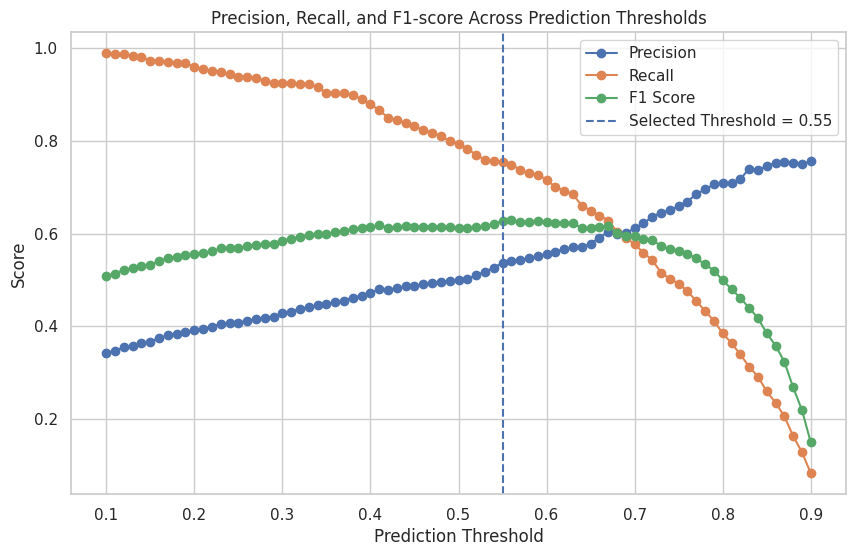

In [19]:
# ============================================================
# Step 16: Threshold Performance Visualization
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["F1_Score"],
    marker="o",
    label="F1 Score"
)

plt.axvline(
    x=best_threshold,
    linestyle="--",
    label=f"Selected Threshold = {best_threshold:.2f}"
)

plt.title("Precision, Recall, and F1-score Across Prediction Thresholds")
plt.xlabel("Prediction Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
# ============================================================
# Step 17: Business Risk Categorization
# ============================================================

def categorize_churn_risk(probability):
    """
    Convert churn probability into business-friendly risk categories.
    """

    if probability >= 0.70:
        return "High Risk"
    elif probability >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"


def recommend_business_action(risk_category):
    """
    Recommend business action based on churn risk level.
    """

    if risk_category == "High Risk":
        return "Immediate retention offer or customer support follow-up"
    elif risk_category == "Medium Risk":
        return "Monitor customer and offer personalized engagement"
    else:
        return "Maintain regular customer relationship"


risk_analysis_df = X_test.copy()

risk_analysis_df["Actual_Churn"] = y_test.values
risk_analysis_df["Predicted_Churn_Probability"] = y_proba_best
risk_analysis_df["Predicted_Churn"] = y_pred_tuned

risk_analysis_df["Risk_Category"] = risk_analysis_df["Predicted_Churn_Probability"].apply(
    categorize_churn_risk
)

risk_analysis_df["Recommended_Action"] = risk_analysis_df["Risk_Category"].apply(
    recommend_business_action
)

print("Risk Category Distribution:")
display(risk_analysis_df["Risk_Category"].value_counts())

print("\nActual churn rate by risk category:")
display(
    round(
        risk_analysis_df.groupby("Risk_Category")["Actual_Churn"]
        .mean()
        .sort_values(ascending=False) * 100,
        2
    )
)

print("\nSample business-ready prediction output:")
display(
    risk_analysis_df[
        [
            "Predicted_Churn_Probability",
            "Predicted_Churn",
            "Risk_Category",
            "Recommended_Action",
            "Actual_Churn"
        ]
    ].head(10)
)

Risk Category Distribution:


Risk_Category
Low Risk       712
High Risk      353
Medium Risk    344
Name: count, dtype: int64


Actual churn rate by risk category:


Risk_Category
High Risk      61.19
Medium Risk    32.85
Low Risk        6.32
Name: Actual_Churn, dtype: float64


Sample business-ready prediction output:


,Predicted_Churn_Probability,Predicted_Churn,Risk_Category,Recommended_Action,Actual_Churn
437,0.110656,0,Low Risk,Maintain regular customer relationship,0
2280,0.880540,1,High Risk,Immediate retention offer or customer support ...,0
2235,0.134465,0,Low Risk,Maintain regular customer relationship,0
4460,0.591599,1,Medium Risk,Monitor customer and offer personalized engage...,0
3761,0.068689,0,Low Risk,Maintain regular customer relationship,0
5748,0.767373,1,High Risk,Immediate retention offer or customer support ...,0
3568,0.640946,1,Medium Risk,Monitor customer and offer personalized engage...,0
2976,0.248443,0,Low Risk,Maintain regular customer relationship,0
5928,0.013957,0,Low Risk,Maintain regular customer relationship,0
1639,0.567186,1,Medium Risk,Monitor customer and offer personalized engage...,1


Top 20 important features:


,Feature,Coefficient,Absolute_Importance,Impact_on_Churn
1,num__tenure,-1.023080,1.023080,Decreases Churn Probability
18,cat__InternetService_Fiber optic,0.716497,0.716497,Increases Churn Probability
17,cat__InternetService_DSL,-0.643083,0.643083,Decreases Churn Probability
40,cat__Contract_Two year,-0.598700,0.598700,Decreases Churn Probability
2,num__MonthlyCharges,-0.542994,0.542994,Decreases Churn Probability
53,cat__IsMonthToMonth_No,-0.416134,0.416134,Decreases Churn Probability
48,cat__TenureGroup_13-24 months,-0.369475,0.369475,Decreases Churn Probability
50,cat__TenureGroup_49-72 months,0.332464,0.332464,Increases Churn Probability
37,cat__StreamingMovies_Yes,0.279533,0.279533,Increases Churn Probability
34,cat__StreamingTV_Yes,0.270211,0.270211,Increases Churn Probability


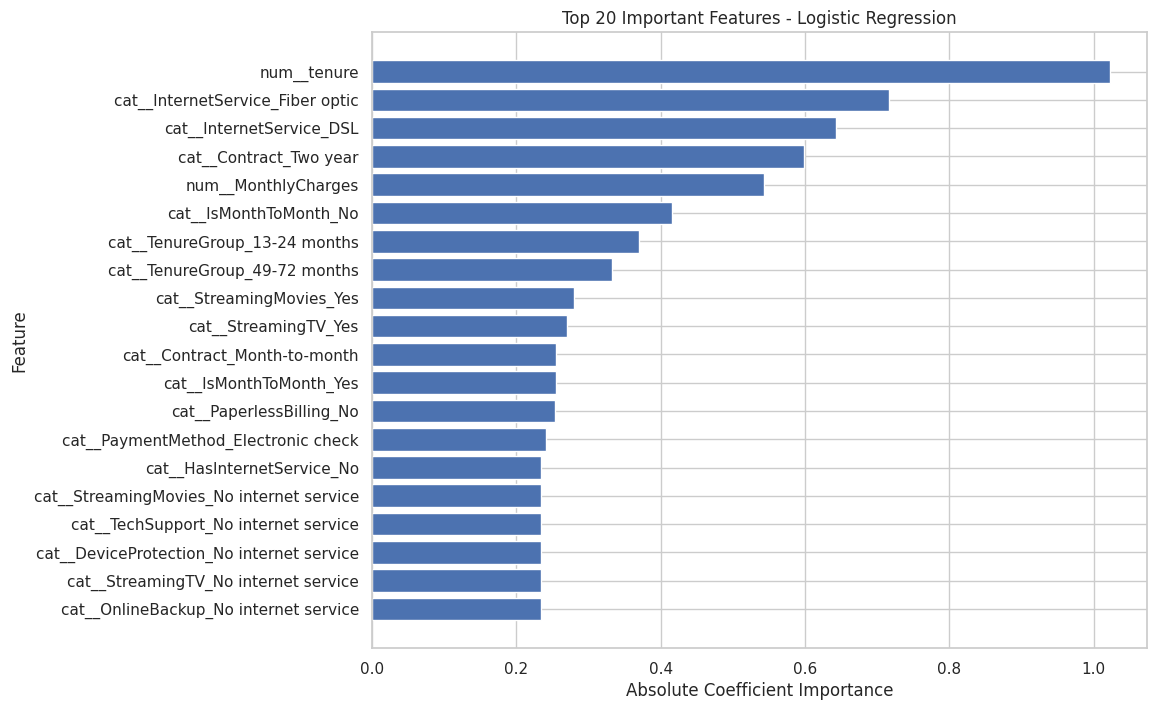


Top features increasing churn probability:


,Feature,Coefficient,Absolute_Importance,Impact_on_Churn
18,cat__InternetService_Fiber optic,0.716497,0.716497,Increases Churn Probability
50,cat__TenureGroup_49-72 months,0.332464,0.332464,Increases Churn Probability
37,cat__StreamingMovies_Yes,0.279533,0.279533,Increases Churn Probability
34,cat__StreamingTV_Yes,0.270211,0.270211,Increases Churn Probability
38,cat__Contract_Month-to-month,0.254872,0.254872,Increases Churn Probability
54,cat__IsMonthToMonth_Yes,0.254872,0.254872,Increases Churn Probability
45,cat__PaymentMethod_Electronic check,0.240369,0.240369,Increases Churn Probability
20,cat__OnlineSecurity_No,0.197856,0.197856,Increases Churn Probability
3,num__TotalCharges,0.186786,0.186786,Increases Churn Probability
39,cat__Contract_One year,0.182566,0.182566,Increases Churn Probability



Top features decreasing churn probability:


,Feature,Coefficient,Absolute_Importance,Impact_on_Churn
1,num__tenure,-1.023080,1.023080,Decreases Churn Probability
17,cat__InternetService_DSL,-0.643083,0.643083,Decreases Churn Probability
40,cat__Contract_Two year,-0.598700,0.598700,Decreases Churn Probability
2,num__MonthlyCharges,-0.542994,0.542994,Decreases Churn Probability
53,cat__IsMonthToMonth_No,-0.416134,0.416134,Decreases Churn Probability
48,cat__TenureGroup_13-24 months,-0.369475,0.369475,Decreases Churn Probability
41,cat__PaperlessBilling_No,-0.252914,0.252914,Decreases Churn Probability
51,cat__HasInternetService_No,-0.234675,0.234675,Decreases Churn Probability
36,cat__StreamingMovies_No internet service,-0.234675,0.234675,Decreases Churn Probability
33,cat__StreamingTV_No internet service,-0.234675,0.234675,Decreases Churn Probability


In [21]:
# ============================================================
# Step 18: Model Explainability Using Feature Importance
# ============================================================

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

classifier = best_model.named_steps["classifier"]

if hasattr(classifier, "coef_"):
    coefficient_values = classifier.coef_[0]

    feature_importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficient_values,
        "Absolute_Importance": np.abs(coefficient_values)
    })

    feature_importance_df["Impact_on_Churn"] = np.where(
        feature_importance_df["Coefficient"] > 0,
        "Increases Churn Probability",
        "Decreases Churn Probability"
    )

    feature_importance_df = feature_importance_df.sort_values(
        by="Absolute_Importance",
        ascending=False
    )

elif hasattr(classifier, "feature_importances_"):
    importance_values = classifier.feature_importances_

    feature_importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance_values
    })

    feature_importance_df = feature_importance_df.sort_values(
        by="Importance",
        ascending=False
    )

else:
    feature_importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": np.nan
    })

print("Top 20 important features:")
display(feature_importance_df.head(20))

plt.figure(figsize=(10, 8))

if "Absolute_Importance" in feature_importance_df.columns:
    plt.barh(
        feature_importance_df.head(20)["Feature"],
        feature_importance_df.head(20)["Absolute_Importance"]
    )
    plt.xlabel("Absolute Coefficient Importance")
else:
    plt.barh(
        feature_importance_df.head(20)["Feature"],
        feature_importance_df.head(20)["Importance"]
    )
    plt.xlabel("Feature Importance")

plt.ylabel("Feature")
plt.title(f"Top 20 Important Features - {best_model_name}")
plt.gca().invert_yaxis()
plt.show()

if "Coefficient" in feature_importance_df.columns:
    print("\nTop features increasing churn probability:")
    display(
        feature_importance_df.sort_values(
            by="Coefficient",
            ascending=False
        ).head(10)
    )

    print("\nTop features decreasing churn probability:")
    display(
        feature_importance_df.sort_values(
            by="Coefficient",
            ascending=True
        ).head(10)
    )

Top 20 features based on permutation importance:


,Feature,Importance_Mean,Importance_Std
4,tenure,0.129686,0.004116
7,InternetService,0.041011,0.007791
17,MonthlyCharges,0.028007,0.004972
21,IsMonthToMonth,0.012294,0.002618
14,Contract,0.010746,0.002673
19,TenureGroup,0.005141,0.001563
13,StreamingMovies,0.003922,0.002040
12,StreamingTV,0.003526,0.002466
23,AverageChargesPerTenure,0.003393,0.001445
8,OnlineSecurity,0.003211,0.001148


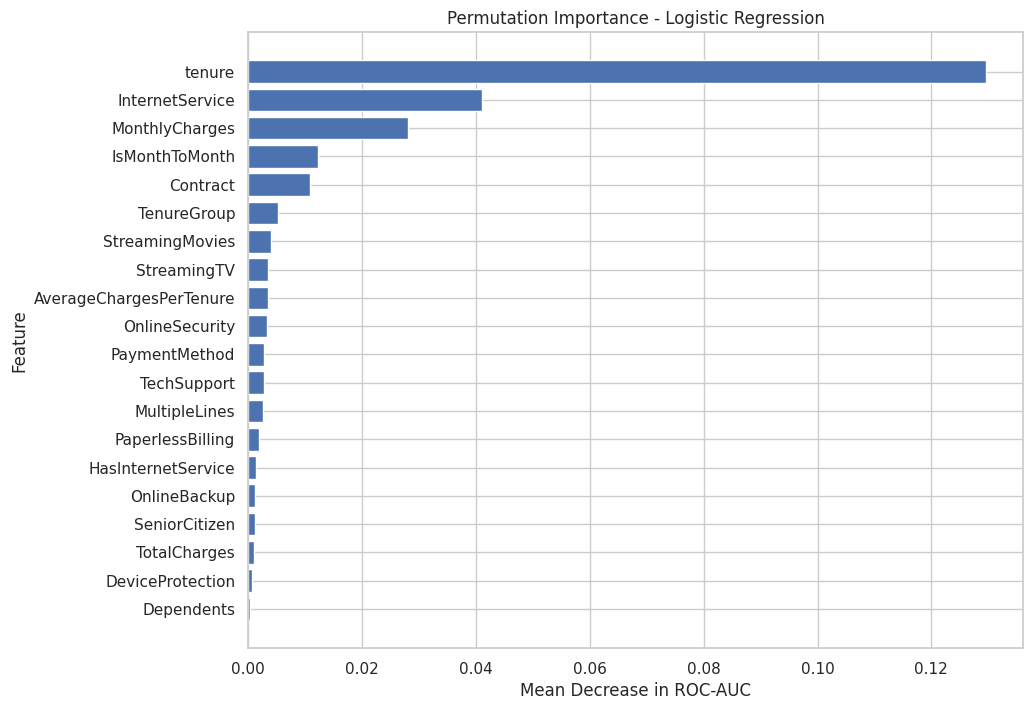

In [22]:
# ============================================================
# Step 18B: Model-Agnostic Permutation Importance
# ============================================================

from sklearn.inspection import permutation_importance

# Permutation importance evaluates how much model performance drops
# when each feature is randomly shuffled.
# This provides a cleaner, model-agnostic interpretation using original feature names.

perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

permutation_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": perm_importance.importances_mean,
    "Importance_Std": perm_importance.importances_std
}).sort_values(by="Importance_Mean", ascending=False)

print("Top 20 features based on permutation importance:")
display(permutation_importance_df.head(20))

plt.figure(figsize=(10, 8))
plt.barh(
    permutation_importance_df.head(20)["Feature"],
    permutation_importance_df.head(20)["Importance_Mean"]
)

plt.xlabel("Mean Decrease in ROC-AUC")
plt.ylabel("Feature")
plt.title(f"Permutation Importance - {best_model_name}")
plt.gca().invert_yaxis()
plt.show()

In [23]:
# ============================================================
# Step 19: Save Model Artifacts for Deployment
# ============================================================

import os
import json
import joblib

artifact_dir = "/kaggle/working/model_artifacts"
os.makedirs(artifact_dir, exist_ok=True)

model_path = os.path.join(artifact_dir, "customer_churn_prediction_pipeline.pkl")
metadata_path = os.path.join(artifact_dir, "model_metadata.json")
coefficient_importance_path = os.path.join(artifact_dir, "coefficient_feature_importance.csv")
permutation_importance_path = os.path.join(artifact_dir, "permutation_importance.csv")
threshold_results_path = os.path.join(artifact_dir, "threshold_results.csv")
final_performance_path = os.path.join(artifact_dir, "final_model_performance.csv")
risk_analysis_path = os.path.join(artifact_dir, "risk_analysis_sample.csv")

# Save trained model pipeline
joblib.dump(best_model, model_path)

# Final performance table
final_performance_df = pd.DataFrame([
    {
        "Best_Model": best_model_name,
        "Selected_Threshold": best_threshold,
        "Accuracy": final_accuracy,
        "Precision": final_precision,
        "Recall": final_recall,
        "F1_Score": final_f1,
        "ROC_AUC": final_roc_auc
    }
])

# Save supporting files
feature_importance_df.to_csv(coefficient_importance_path, index=False)
permutation_importance_df.to_csv(permutation_importance_path, index=False)
threshold_results_df.to_csv(threshold_results_path, index=False)
final_performance_df.to_csv(final_performance_path, index=False)
risk_analysis_df.head(100).to_csv(risk_analysis_path, index=False)

# Save metadata for deployment and documentation
model_metadata = {
    "project_name": "Customer Churn Prediction System",
    "project_type": "End-to-End Machine Learning Classification Project",
    "best_model": best_model_name,
    "selected_threshold": best_threshold,
    "target_mapping": {
        "No Churn": 0,
        "Churn": 1
    },
    "final_metrics": {
        "accuracy": final_accuracy,
        "precision": final_precision,
        "recall": final_recall,
        "f1_score": final_f1,
        "roc_auc": final_roc_auc
    },
    "business_output": {
        "low_risk": "Probability below 40%",
        "medium_risk": "Probability between 40% and 70%",
        "high_risk": "Probability 70% or above"
    },
    "top_business_features": permutation_importance_df.head(10)["Feature"].tolist(),
    "features_used": X.columns.tolist(),
    "explainability_methods": [
        "Logistic Regression coefficients",
        "Permutation importance"
    ]
}

with open(metadata_path, "w") as file:
    json.dump(model_metadata, file, indent=4)

print("Model artifacts saved successfully.")
print("=" * 70)
print(f"Model pipeline saved at                 : {model_path}")
print(f"Model metadata saved at                 : {metadata_path}")
print(f"Coefficient importance saved at         : {coefficient_importance_path}")
print(f"Permutation importance saved at         : {permutation_importance_path}")
print(f"Threshold results saved at              : {threshold_results_path}")
print(f"Final performance saved at              : {final_performance_path}")
print(f"Risk analysis sample saved at           : {risk_analysis_path}")

display(final_performance_df)

Model artifacts saved successfully.
Model pipeline saved at                 : /kaggle/working/model_artifacts/customer_churn_prediction_pipeline.pkl
Model metadata saved at                 : /kaggle/working/model_artifacts/model_metadata.json
Coefficient importance saved at         : /kaggle/working/model_artifacts/coefficient_feature_importance.csv
Permutation importance saved at         : /kaggle/working/model_artifacts/permutation_importance.csv
Threshold results saved at              : /kaggle/working/model_artifacts/threshold_results.csv
Final performance saved at              : /kaggle/working/model_artifacts/final_model_performance.csv
Risk analysis sample saved at           : /kaggle/working/model_artifacts/risk_analysis_sample.csv


,Best_Model,Selected_Threshold,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.55,0.762243,0.537143,0.754011,0.627364,0.842104


In [24]:
# ============================================================
# Step 20: Production-Style Churn Prediction Function
# ============================================================

def prepare_customer_features(customer_data):
    """
    Prepare customer data for prediction.
    If engineered features are missing, create them automatically.
    """

    required_engineered_features = [
        "TenureGroup",
        "HasInternetService",
        "IsMonthToMonth",
        "NumberOfSupportServices",
        "AverageChargesPerTenure"
    ]

    data = customer_data.copy()

    missing_engineered_features = [
        feature for feature in required_engineered_features
        if feature not in data.columns
    ]

    if len(missing_engineered_features) > 0:
        data = create_customer_churn_features(data)

    return data


def predict_customer_churn(customer_data, model, threshold):
    """
    Predict customer churn probability, churn class, risk category,
    and recommended business action.

    Parameters:
    customer_data: pd.DataFrame
        Customer information for prediction.

    model: sklearn Pipeline
        Trained churn prediction pipeline.

    threshold: float
        Selected business threshold for churn classification.

    Returns:
    pd.DataFrame
        Prediction output with churn probability, predicted class,
        risk category, and recommended action.
    """

    prepared_data = prepare_customer_features(customer_data)

    churn_probability = model.predict_proba(prepared_data)[:, 1]
    predicted_churn = (churn_probability >= threshold).astype(int)

    prediction_output = customer_data.copy()

    prediction_output["Churn_Probability"] = churn_probability
    prediction_output["Predicted_Churn"] = predicted_churn

    prediction_output["Risk_Category"] = prediction_output["Churn_Probability"].apply(
        categorize_churn_risk
    )

    prediction_output["Recommended_Action"] = prediction_output["Risk_Category"].apply(
        recommend_business_action
    )

    return prediction_output


# Test the production-style function with one customer from the test set
sample_customer = X_test.iloc[[0]]

sample_prediction = predict_customer_churn(
    customer_data=sample_customer,
    model=best_model,
    threshold=best_threshold
)

print("Sample prediction output:")
display(
    sample_prediction[
        [
            "Churn_Probability",
            "Predicted_Churn",
            "Risk_Category",
            "Recommended_Action"
        ]
    ]
)

Sample prediction output:


,Churn_Probability,Predicted_Churn,Risk_Category,Recommended_Action
437,0.110656,0,Low Risk,Maintain regular customer relationship


In [25]:
# ============================================================
# Step 21: Create Downloadable Artifact Package
# ============================================================

import zipfile

zip_path = "/kaggle/working/customer_churn_model_artifacts.zip"

with zipfile.ZipFile(zip_path, "w") as zipf:
    for root, dirs, files in os.walk(artifact_dir):
        for file in files:
            file_full_path = os.path.join(root, file)
            archive_name = os.path.relpath(file_full_path, artifact_dir)
            zipf.write(file_full_path, archive_name)

print("Artifact package created successfully.")
print(f"Download path: {zip_path}")

Artifact package created successfully.
Download path: /kaggle/working/customer_churn_model_artifacts.zip
